# IT24100038 — Data Understanding & Data Preparation

**Member:** IT24100038
**Project:** Early Identification of At Risk Students Through Final Mathematics Grade Prediction
**Dataset:** UCI Student Performance — Mathematics (`student-mat.csv`)

## Scope of this notebook

This notebook covers IT24100038's assigned responsibility in the project proposal:

- understanding the dataset's structure and variable types
- assessing data quality (missing values, duplicates, inconsistent or out-of-range values)
- defining and freezing the `Risk_Status` target from `G3` using a justified threshold
- preventing target leakage
- performing the stratified train/test split
- feature engineering and preprocessing (encoding, scaling, imputation)
- providing feature-selection support (mutual information)
- final leakage/integrity checks and preparing the hand-off package for the modelling stage

Full exploratory data analysis (distributions, bivariate relationships, statistical association tests) is IT24101546's responsibility and is covered in their notebook. This notebook only includes the exploration needed to make defensible data-preparation decisions — dataset structure, data quality, and the risk-threshold investigation.

## 1. Setup

In [1]:
# ============================================================
# Imports and plotting configuration
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
# ============================================================
# 2. Load the Mathematics dataset
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Update the path below if you placed student-mat.csv in a subfolder.
# Default assumes the file is in the root of My Drive.
DATA_PATH = '/content/drive/My Drive/student-mat.csv'

# UCI's student-mat.csv is semicolon-separated.
df = pd.read_csv(DATA_PATH, sep=';')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: 395 rows x 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 2. Dataset structure and variable types

The Mathematics dataset contains 395 student records and 33 variables, with one row per student — matching the project's stated unit of analysis. The three Mathematics grades are central to the task:

- `G1` — first-period grade
- `G2` — second-period grade
- `G3` — final grade, used only to construct the `Risk_Status` target, never as a predictor

In [3]:
# ============================================================
# 3. Structural inspection
# ============================================================
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Shape: (395, 33)

Data types:
             dtype
school      object
sex         object
age          int64
address     object
famsize     object
Pstatus     object
Medu         int64
Fedu         int64
Mjob        object
Fjob        object
reason      object
guardian    object
traveltime   int64
studytime    int64
failures     int64
schoolsup   object
famsup      object
paid        object
activities  object
nursery     object
higher      object
internet    object
romantic    object
famrel       int64
freetime     int64
goout        int64
Dalc         int64
Walc         int64
health       int64
absences     int64
G1           int64
G2           int64
G3           int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int6

In [4]:
# Variable-level summary: type, unique values, missingness
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean().mul(100).round(2)
}).sort_values(["dtype", "n_unique"])

print(overview)

,dtype,n_unique,missing,missing_%
traveltime,int64,4,0,0.0
studytime,int64,4,0,0.0
failures,int64,4,0,0.0
Medu,int64,5,0,0.0
Fedu,int64,5,0,0.0
famrel,int64,5,0,0.0
freetime,int64,5,0,0.0
goout,int64,5,0,0.0
Dalc,int64,5,0,0.0
Walc,int64,5,0,0.0


**Why this matters:** establishing the schema before any transformation prevents treating every variable as continuous. Several variables are nominal categories, others are ordered rating scales (e.g. `studytime`, `famrel`, `health`), and each needs different downstream handling.

## 3. Data quality assessment

Checks for missing values, duplicate records, and basic value validity. Unusual values are not removed automatically — an unusual student is still a legitimate observation unless there is evidence the value is erroneous.

In [5]:
# ============================================================
# 4. Missing values and duplicates
# ============================================================
missing = df.isna().sum().sort_values(ascending=False)
print("Total missing cells:", int(df.isna().sum().sum()))
print(missing[missing > 0].to_frame("missing_count"))

print("Exact duplicate rows:", int(df.duplicated().sum()))

Total missing cells: 0


,missing_count


Exact duplicate rows: 0


In [6]:
# ============================================================
# 5. Categorical value inspection
# ============================================================
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).to_frame("count"))


--- school ---


,count
school,
GP,349
MS,46



--- sex ---


,count
sex,
F,208
M,187



--- address ---


...

,count
higher,
yes,375
no,20



--- internet ---


,count
internet,
yes,329
no,66



--- romantic ---


,count
romantic,
no,263
yes,132


**Finding:** no missing cells and no exact duplicate rows. There is no evidence here requiring blanket imputation or duplicate deletion. Categorical-value inspection above confirms there are no inconsistent spellings or unexpected extra categories.

In [7]:
# ============================================================
# 6. Domain/range checks for numeric variables
# ============================================================
expected_ranges = {
    "age": (15, 22),
    "Medu": (0, 4),
    "Fedu": (0, 4),
    "traveltime": (1, 4),
    "studytime": (1, 4),
    "failures": (0, 3),
    "famrel": (1, 5),
    "freetime": (1, 5),
    "goout": (1, 5),
    "Dalc": (1, 5),
    "Walc": (1, 5),
    "health": (1, 5),
    "absences": (0, np.inf),
    "G1": (0, 20),
    "G2": (0, 20),
    "G3": (0, 20),
}

range_results = []
for col, (low, high) in expected_ranges.items():
    if col in df.columns:
        invalid = ((df[col] < low) | (df[col] > high)).sum()
        range_results.append({
            "variable": col,
            "expected_min": low,
            "expected_max": high,
            "observed_min": df[col].min(),
            "observed_max": df[col].max(),
            "invalid_count": int(invalid)
        })

range_check = pd.DataFrame(range_results)
print(range_check)

,variable,expected_min,expected_max,observed_min,observed_max,invalid_count
0,age,15,22.0,15,22,0
1,Medu,0,4.0,0,4,0
2,Fedu,0,4.0,0,4,0
3,traveltime,1,4.0,1,4,0
4,studytime,1,4.0,1,4,0
5,failures,0,3.0,0,3,0
6,famrel,1,5.0,1,5,0
7,freetime,1,5.0,1,5,0
8,goout,1,5.0,1,5,0
9,Dalc,1,5.0,1,5,0


**Interpretation:** all numeric variables fall within their expected domain ranges. Range validation is preferable to automatic outlier deletion — for example, `absences` can legitimately be much larger than the typical value, and removing such rows would discard real information from an already small dataset (395 rows).

## 4. Risk-threshold investigation

`Risk_Status` is not an original column in the UCI dataset — it must be constructed from `G3` using a threshold that is justified by the grading context and by evidence from the data, not chosen arbitrarily or picked to maximize model accuracy. This section compares candidate thresholds before one is frozen for the pipeline.

In [8]:
# ============================================================
# 19. Inspect G3 values around the candidate boundary
# ============================================================
g3_distribution = df["G3"].value_counts().sort_index().to_frame("count")
g3_distribution["percentage"] = (g3_distribution["count"] / len(df) * 100).round(2)

print(g3_distribution)

,count,percentage
G3,,
0,38,9.62
4,1,0.25
5,7,1.77
6,15,3.80
7,9,2.28
8,32,8.10
9,28,7.09
10,56,14.18
11,47,11.90


In [9]:
# ============================================================
# 17. Candidate risk thresholds
# ============================================================
candidate_thresholds = [8, 9, 10, 11, 12]

threshold_analysis = []
for threshold in candidate_thresholds:
    at_risk = (df["G3"] < threshold)
    n_at_risk = int(at_risk.sum())
    n_not_risk = int((~at_risk).sum())

    threshold_analysis.append({
        "Threshold": f"G3 < {threshold}",
        "Threshold_value": threshold,
        "At_Risk_n": n_at_risk,
        "At_Risk_%": round(n_at_risk / len(df) * 100, 2),
        "Not_At_Risk_n": n_not_risk,
        "Not_At_Risk_%": round(n_not_risk / len(df) * 100, 2)
    })

threshold_df = pd.DataFrame(threshold_analysis)
print(threshold_df)

,Threshold,Threshold_value,At_Risk_n,At_Risk_%,Not_At_Risk_n,Not_At_Risk_%
0,G3 < 8,8,70,17.72,325,82.28
1,G3 < 9,9,102,25.82,293,74.18
2,G3 < 10,10,130,32.91,265,67.09
3,G3 < 11,11,186,47.09,209,52.91
4,G3 < 12,12,233,58.99,162,41.01


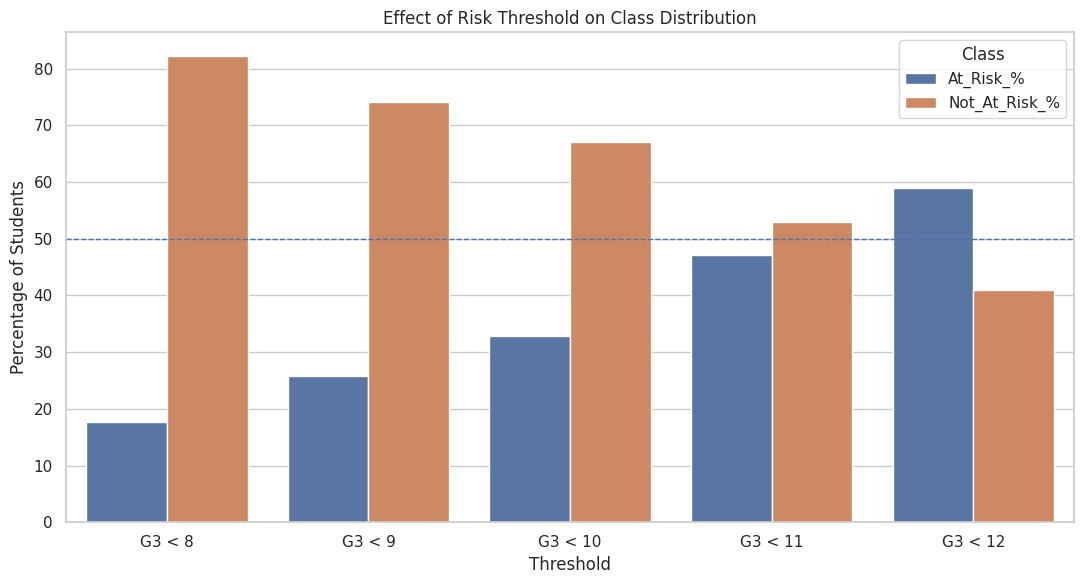

In [10]:
# ============================================================
# 18. Visual comparison of candidate class balances
# ============================================================
plot_df = threshold_df.melt(
    id_vars=["Threshold"],
    value_vars=["At_Risk_%", "Not_At_Risk_%"],
    var_name="Class",
    value_name="Percentage"
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="Threshold", y="Percentage", hue="Class")
plt.axhline(50, linestyle="--", linewidth=1)
plt.title("Effect of Risk Threshold on Class Distribution")
plt.ylabel("Percentage of Students")
plt.tight_layout()
plt.show()

**Threshold decision framework.** A threshold should not be chosen because it produces the best downstream accuracy — it defines the business meaning of the target itself. Candidate thresholds are evaluated on:

1. educational/grading interpretation (Mathematics grades here run 0–20, and 10/20 is the conventional pass/fail cutoff),
2. the resulting number and percentage of At-Risk students,
3. whether the positive class is large enough for meaningful evaluation later,
4. how well the resulting definition matches the project's business objective.

A different threshold changes the number of At-Risk students, the class balance, and potentially model performance — so this choice is treated as a project decision, not a default.

**Candidate chosen for the pipeline:** `G3 < 10`. It produces a 67% / 33% split — a substantial minority At-Risk group rather than an extremely rare class — and aligns with the conventional pass/fail boundary on the 0–20 grading scale. This is treated as an evidence-based project decision, not a universal definition of academic risk; if the group agrees on a different threshold, only `RISK_THRESHOLD` needs to change and the notebook re-run from that point.

## 5. Data preparation

The remainder of this notebook builds the modelling-ready dataset: the target variable, the leakage-safe predictor set, the train/test split, feature engineering, and preprocessing.

**Guiding principle:** fit anything that learns from the data (imputers, scalers, encoders, feature selection) only on the training data, or inside cross-validation. This prevents preprocessing and feature-selection leakage into the test set.

**Prediction-time framing:** `G3` is the final Mathematics grade and is used to construct `Risk_Status`, so it must never be used as an input feature — including it would directly reveal the answer to the model. `G1` and `G2` are retained as predictors because they represent grades issued *before* `G3`, consistent with the project's proposed prediction point (Student Information + G1 + G2 → Risk Status).

### 5.1 Final duplicate check before building the pipeline

In [11]:
# ============================================================
# Final duplicate check and copy for the preparation pipeline
# ============================================================
df_prep = df.copy()

duplicate_count = int(df_prep.duplicated().sum())

if duplicate_count > 0:
    df_prep = df_prep.drop_duplicates().reset_index(drop=True)
    print(f"Removed {duplicate_count} exact duplicate rows.")
else:
    print("No exact duplicate rows found; no rows removed.")

print("Shape going into the pipeline:", df_prep.shape)


No exact duplicate rows found; no rows removed.
Shape going into the pipeline: (395, 33)


Only exact duplicate records are candidates for removal, since they are repeated records rather than unusual student observations. This dataset has none, so no rows are dropped.

### 5.2 Target definition — `Risk_Status`

In [12]:
# ============================================================
# 40. Freeze the project candidate threshold
# ============================================================
RISK_THRESHOLD = 10

df_prep["Risk_Status"] = (
    df_prep["G3"] < RISK_THRESHOLD
).astype(int)

# Convention:
# 1 = At Risk
# 0 = Not At Risk

print(f"Target rule: At Risk if G3 < {RISK_THRESHOLD}")
print(
    df_prep["Risk_Status"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Not At Risk", 1: "At Risk"})
    .to_frame("count")
    .assign(percentage=lambda x: (x["count"] / len(df_prep) * 100).round(2))
)

Target rule: At Risk if G3 < 10


,count,percentage
Risk_Status,,
Not At Risk,265,67.09
At Risk,130,32.91


For this notebook, the threshold is frozen as: **`Risk_Status = 1` when `G3 < 10`; otherwise `0`.** This matches the candidate identified in the threshold investigation above.

### 5.3 Leakage prevention

`G3` is used to create `Risk_Status`, so including `G3` in `X` would directly reveal the answer to the model. Both `G3` and `Risk_Status` are explicitly removed from the predictor matrix, and this is asserted rather than assumed.

In [13]:
# ============================================================
# 41. Build X and y with explicit leakage prevention
# ============================================================
TARGET = "Risk_Status"
LEAKAGE_COLUMNS = ["G3", TARGET]

X_raw = df_prep.drop(columns=LEAKAGE_COLUMNS)
y = df_prep[TARGET].copy()

print("X shape:", X_raw.shape)
print("y shape:", y.shape)

print("\nLeakage columns removed:", LEAKAGE_COLUMNS)
print("G3 in X?", "G3" in X_raw.columns)
print("Risk_Status in X?", "Risk_Status" in X_raw.columns)

assert "G3" not in X_raw.columns
assert TARGET not in X_raw.columns

X shape: (395, 32)
y shape: (395,)

Leakage columns removed: ['G3', 'Risk_Status']
G3 in X? False
Risk_Status in X? False


### 5.4 Prediction-time feature audit

A feature can be statistically useful but operationally invalid if it is only known after the point at which the risk prediction is meant to be made. The predictor list below is passed to the team for confirmation before final submission.

In [14]:
# ============================================================
# 42. Predictor inventory
# ============================================================
feature_inventory = pd.DataFrame({
    "feature": X_raw.columns,
    "dtype": X_raw.dtypes.astype(str).values,
    "n_unique": [X_raw[c].nunique() for c in X_raw.columns]
})

print(feature_inventory)

,feature,dtype,n_unique
0,school,object,2
1,sex,object,2
2,age,int64,8
3,address,object,2
4,famsize,object,2
5,Pstatus,object,2
6,Medu,int64,5
7,Fedu,int64,5
8,Mjob,object,5
9,Fjob,object,5


`G1` and `G2` are intentionally retained because the project identifies them as earlier-period academic information available before `G3`. If the intended prediction point is actually before G1 or before G2 in some deployment scenario, those grades would need to be excluded — this is a business-definition decision for the team to confirm, not something the preprocessing code should decide silently.

### 5.5 Stratified train/test split

An 80/20 stratified split preserves the target-class proportions in both sets. The test set is held back for final evaluation only and is not touched during preprocessing fitting, feature selection, or model tuning.

In [15]:
# ============================================================
# 43. Stratified 80/20 train-test split
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

split_check = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "train_%": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
    "test_count": y_test.value_counts().sort_index(),
    "test_%": (y_test.value_counts(normalize=True).sort_index() * 100).round(2)
}).rename(index={0: "Not At Risk", 1: "At Risk"})

print(split_check)

X_train: (316, 32)
X_test : (79, 32)
y_train: (316,)
y_test : (79,)


,train_count,train_%,test_count,test_%
Risk_Status,,,,
Not At Risk,212,67.09,53,67.09
At Risk,104,32.91,26,32.91


### 5.6 Feature engineering

Kept deliberately small and domain-motivated rather than adding many arbitrary combinations, and computed only from `G1`/`G2`/`absences` — never from `G3`:

1. `previous_grade_avg = (G1 + G2) / 2` — overall prior achievement
2. `grade_change = G2 - G1` — improvement or decline between the two known assessments
3. `log_absences = log1p(absences)` — reduces the influence of the right-skewed tail in attendance counts

These are candidate features, not guaranteed improvements — the modelling team should compare results with and without them using cross-validation. Because `previous_grade_avg` and `grade_change` are linear combinations of `G1` and `G2`, they carry no independent information beyond them and should be treated as alternate representations rather than automatically added on top of the raw grades.

In [16]:
# ============================================================
# 44. Feature engineering on train and test
# ============================================================
def add_engineered_features(X):
    X = X.copy()

    if {"G1", "G2"}.issubset(X.columns):
        X["previous_grade_avg"] = (X["G1"] + X["G2"]) / 2
        X["grade_change"] = X["G2"] - X["G1"]

    if "absences" in X.columns:
        X["log_absences"] = np.log1p(X["absences"])

    return X

X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

print("Training features:", X_train_fe.shape[1])
print("Testing features :", X_test_fe.shape[1])

print(X_train_fe[["G1", "G2", "previous_grade_avg", "grade_change", "absences", "log_absences"]].head())

Training features: 35
Testing features : 35


,G1,G2,previous_grade_avg,grade_change,absences,log_absences
101,16,17,16.5,1,0,0.000000
63,10,9,9.5,-1,2,1.098612
245,18,18,18.0,0,6,1.945910
112,10,13,11.5,3,6,1.945910
8,16,18,17.0,2,0,0.000000


### 5.7 Identifying feature types

Not every integer column is a continuous measurement — several variables are ordered scales (`studytime`, `famrel`, `health`, `Medu`, `Fedu`, etc.) whose numeric ordering carries information, so they are kept numeric rather than one-hot encoded. Nominal categorical variables are handled separately.

In [17]:
# ============================================================
# 45. Define numerical/ordinal vs nominal categorical groups
# ============================================================
ordinal_cols = [
    "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health"
]

nominal_cols = [
    "school", "sex", "address", "famsize", "Pstatus",
    "Mjob", "Fjob", "reason", "guardian",
    "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic"
]

continuous_cols = [
    "age", "absences", "G1", "G2",
    "previous_grade_avg", "grade_change", "log_absences"
]

# Keep only columns actually present.
ordinal_cols = [c for c in ordinal_cols if c in X_train_fe.columns]
nominal_cols = [c for c in nominal_cols if c in X_train_fe.columns]
continuous_cols = [c for c in continuous_cols if c in X_train_fe.columns]

print("Continuous:", continuous_cols)
print("Ordinal   :", ordinal_cols)
print("Nominal   :", nominal_cols)

assert set(continuous_cols + ordinal_cols + nominal_cols) == set(X_train_fe.columns)

Continuous: ['age', 'absences', 'G1', 'G2', 'previous_grade_avg', 'grade_change', 'log_absences']
Ordinal   : ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
Nominal   : ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


### 5.8 Preprocessing pipelines

Two parallel `ColumnTransformer` pipelines are built because different model families need different treatment: linear/margin-based models (Logistic Regression, SVM) benefit from scaling, while tree-based models do not need it. Preprocessing must be learned from the training data only, so both pipelines are fit on `X_train_fe` and only applied (`transform`) to `X_test_fe`.

In [18]:
# ============================================================
# 46. Preprocessing pipelines
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

continuous_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer([
    ("continuous", continuous_preprocessor, continuous_cols),
    ("ordinal", ordinal_preprocessor, ordinal_cols),
    ("categorical", categorical_preprocessor, nominal_cols)
])

# Tree-based alternative: no scaling required.
continuous_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

ordinal_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_tree = ColumnTransformer([
    ("continuous", continuous_tree, continuous_cols),
    ("ordinal", ordinal_tree, ordinal_cols),
    ("categorical", categorical_preprocessor, nominal_cols)
])

print("Preprocessors created successfully.")

Preprocessors created successfully.


In [19]:
# ============================================================
# 47. Fit preprocessing ONLY on training data
# ============================================================
X_train_scaled = preprocessor_scaled.fit_transform(X_train_fe)
X_test_scaled = preprocessor_scaled.transform(X_test_fe)

X_train_tree = preprocessor_tree.fit_transform(X_train_fe)
X_test_tree = preprocessor_tree.transform(X_test_fe)

print("Scaled train matrix:", X_train_scaled.shape)
print("Scaled test matrix :", X_test_scaled.shape)
print("Tree train matrix  :", X_train_tree.shape)
print("Tree test matrix   :", X_test_tree.shape)

Scaled train matrix: (316, 61)
Scaled test matrix : (79, 61)
Tree train matrix  : (316, 61)
Tree test matrix   : (79, 61)


In [20]:
# ============================================================
# 48. Confirm feature names after one-hot encoding
# ============================================================
feature_names = preprocessor_scaled.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(pd.Series(feature_names, name="transformed_feature").head(50).to_frame())

Number of transformed features: 61


,transformed_feature
0,continuous__age
1,continuous__absences
2,continuous__G1
3,continuous__G2
4,continuous__previous_grade_avg
5,continuous__grade_change
6,continuous__log_absences
7,ordinal__Medu
8,ordinal__Fedu
9,ordinal__traveltime


### 5.9 Class balance check

With the frozen threshold, the At-Risk group is a meaningful minority (about a third of students) rather than an extremely rare class, so stratification is essential but aggressive resampling (e.g. SMOTE) is not applied by default here — it is left as an optional experiment for the modelling stage, to be tested inside cross-validation folds only if needed.

In [21]:
# ============================================================
# 49. Final target balance report
# ============================================================
target_report = pd.DataFrame({
    "class": ["Not At Risk", "At Risk"],
    "label": [0, 1],
    "train_n": [
        int((y_train == 0).sum()),
        int((y_train == 1).sum())
    ],
    "test_n": [
        int((y_test == 0).sum()),
        int((y_test == 1).sum())
    ]
})

target_report["train_%"] = (
    target_report["train_n"] / len(y_train) * 100
).round(2)

target_report["test_%"] = (
    target_report["test_n"] / len(y_test) * 100
).round(2)

print(target_report)

,class,label,train_n,test_n,train_%,test_%
0,Not At Risk,0,212,53,67.09,67.09
1,At Risk,1,104,26,32.91,32.91


### 5.10 Feature-selection support

Feature selection is the responsibility of the downstream modelling workflow, but a leakage-safe starting point is provided here using mutual information, computed on the training set only. This is a screening tool, not proof that a feature belongs in the final model — the modelling member should compare selected and non-selected versions using stratified cross-validation.

In [22]:
# ============================================================
# 50. Training-only feature selection support: mutual information
# ============================================================
from sklearn.feature_selection import mutual_info_classif

# Convert sparse/dense safely for MI.
X_mi = X_train_scaled.toarray() if hasattr(X_train_scaled, "toarray") else X_train_scaled

mi_scores = mutual_info_classif(
    X_mi,
    y_train,
    random_state=42
)

mi_df = (
    pd.DataFrame({
        "feature": feature_names,
        "mutual_information": mi_scores
    })
    .sort_values("mutual_information", ascending=False)
)

print(mi_df.head(20))

,feature,mutual_information
4,continuous__previous_grade_avg,0.447528
3,continuous__G2,0.444011
2,continuous__G1,0.337883
11,ordinal__failures,0.092952
32,categorical__Mjob_teacher,0.074373
56,categorical__higher_yes,0.053527
25,categorical__famsize_LE3,0.045705
35,categorical__Fjob_other,0.044361
50,categorical__paid_yes,0.040796
14,ordinal__goout,0.034596


### 5.11 Final leakage and integrity audit

Before handing the dataset off, explicit assertions confirm there is no leakage and the split is structurally sound.

In [23]:
# ============================================================
# 51. Final leakage and integrity assertions
# ============================================================

# Target and final grade must not be in raw predictors.
assert "G3" not in X_raw.columns
assert "Risk_Status" not in X_raw.columns

# Neither should appear in the engineered predictor matrices.
assert "G3" not in X_train_fe.columns
assert "Risk_Status" not in X_train_fe.columns
assert "G3" not in X_test_fe.columns
assert "Risk_Status" not in X_test_fe.columns

# Train/test row counts must match.
assert len(X_train_fe) == len(y_train)
assert len(X_test_fe) == len(y_test)

# Test rows must not overlap with training rows by original index.
assert set(X_train.index).isdisjoint(set(X_test.index))

# Class labels must be binary.
assert set(y.unique()).issubset({0, 1})

print("✓ No G3 leakage")
print("✓ No target leakage")
print("✓ Train/test sizes consistent")
print("✓ Train/test indices disjoint")
print("✓ Binary target verified")

✓ No G3 leakage
✓ No target leakage
✓ Train/test sizes consistent
✓ Train/test indices disjoint
✓ Binary target verified


### 5.12 Final hand-off package

Summary of everything the modelling member (IT24101024) needs to start training and comparing classifiers.

In [24]:
# ============================================================
# 52. Final hand-off summary
# ============================================================
handoff = {
    "target": TARGET,
    "risk_rule": f"G3 < {RISK_THRESHOLD}",
    "positive_class": "At Risk (1)",
    "negative_class": "Not At Risk (0)",
    "raw_predictor_count": X_raw.shape[1],
    "engineered_predictor_count": X_train_fe.shape[1],
    "train_rows": len(X_train_fe),
    "test_rows": len(X_test_fe),
    "split": "80/20 stratified",
    "random_state": 42,
    "leakage_excluded": ["G3", "Risk_Status"],
    "engineered_features": ["previous_grade_avg", "grade_change", "log_absences"],
    "preprocessing": [
        "median imputation",
        "one-hot encoding for nominal categorical variables",
        "standardization for scaled models",
        "no scaling required for tree-based models"
    ],
    "smote": "Not applied automatically; if tested, apply inside CV training folds only.",
    "pca": "Not required for this small, interpretable tabular dataset."
}

for k, v in handoff.items():
    print(f"{k}: {v}")

target: Risk_Status
risk_rule: G3 < 10
positive_class: At Risk (1)
negative_class: Not At Risk (0)
raw_predictor_count: 32
engineered_predictor_count: 35
train_rows: 316
test_rows: 79
split: 80/20 stratified
random_state: 42
leakage_excluded: ['G3', 'Risk_Status']
engineered_features: ['previous_grade_avg', 'grade_change', 'log_absences']
preprocessing: ['median imputation', 'one-hot encoding for nominal categorical variables', 'standardization for scaled models', 'no scaling required for tree-based models']
smote: Not applied automatically; if tested, apply inside CV training folds only.
pca: Not required for this small, interpretable tabular dataset.


### 5.13 Export Final Datasets

Save the finalized, feature-engineered datasets and targets to CSV files so they can be easily loaded in the modelling phase notebook (IT24101024).

In [ ]:
# ============================================================
# 53. Export final datasets to CSV
# ============================================================
# Save the feature-engineered DataFrames and target Series
X_train_fe.to_csv("X_train_fe.csv", index=False)
X_test_fe.to_csv("X_test_fe.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Datasets successfully exported to CSV:")
print(" - X_train_fe.csv")
print(" - X_test_fe.csv")
print(" - y_train.csv")
print(" - y_test.csv")


## 6. Decision log

| Decision | Choice | Reason |
|---|---|---|
| Missing values | Checked; pipeline-safe imputation included | Dataset currently has no missing cells, but the pipeline should still handle them robustly |
| Duplicates | Remove only exact duplicates if present | Avoid deleting legitimate unusual students |
| Outliers | Investigated via range checks, not blindly deleted | Extreme values can be valid educational observations |
| Target | `Risk_Status` from `G3` | Required by the project proposal |
| Threshold | `G3 < 10` | Aligns with the 0–20 pass/fail convention and produces a substantial minority class (33% At Risk) |
| `G3` as predictor | Never | Direct target leakage |
| Split | 80/20 stratified | Preserves class proportions in train and test |
| Categorical encoding | One-hot for nominal variables | Appropriate representation for unordered categories |
| Ordinal handling | Kept as ordered numeric values | Preserves ordering information |
| Scaling | Applied for linear/SVM-style models only | Trees do not require standardized inputs |
| Feature engineering | Grade average, grade change, log absences | Domain-motivated and limited in scope |
| Feature selection | Mutual information provided as a candidate screen | Final selection is the modelling member's responsibility |
| SMOTE | Not applied by default | Class imbalance here (67/33) is moderate, not severe |
| PCA | Not used | Reduces interpretability and is unnecessary for this small, tabular dataset |
| Test-set usage | Reserved for final evaluation only | Prevents optimistic performance estimates during model selection |

## What this notebook covers

**Dataset understanding:** structure, variable types, data-quality checks (missing values, duplicates, range validity).

**Data preparation:** target creation and threshold justification, leakage prevention, prediction-time feature audit, stratified train/test split, feature engineering, preprocessing pipelines (scaled and tree variants), feature-selection support, final integrity assertions, and the model-ready hand-off package.

